# 03 -- Modele Bayesien (PyMC)
## VelibMMM -- Prediction fill_rate(t+30min)

**Objectif :** estimer la distribution posterieure des coefficients
d'un modele de regression Beta pour predire la disponibilite des stations Velib.

### Pourquoi les chaines de Markov ?

On cherche P(theta | donnees) -- la distribution posterieure des parametres.
Cette distribution est rarement calculable analytiquement.

**MCMC (Markov Chain Monte Carlo) :** on construit une chaine de Markov
dont la **distribution stationnaire** est exactement P(theta | donnees).
Apres suffisamment de pas, les echantillons de la chaine sont des tirages
de la posterieure -- sans jamais avoir besoin de la calculer explicitement.

**NUTS (No-U-Turn Sampler) :** variante adaptative de HMC utilisee par PyMC.
Utilise le gradient de log P(theta | donnees) pour explorer l'espace
efficacement, meme en haute dimension.

---
### Modele

```
fill_rate_t30 ~ Beta(mu * kappa, (1-mu) * kappa)

logit(mu) = alpha
          + beta_fr       * fill_rate(t)          # autoregression
          + beta_adstock  * adstock_drain(t)       # memoire drainage
          + beta_drain    * drainage(t)            # drainage instantane
          + beta_neighbor * neighbor_fr_mean(t)    # voisinage
          + beta_rush     * is_rush(t)             # heure de pointe
          + beta_hsin     * hour_sin(t)            # periodicite heure
          + beta_hcos     * hour_cos(t)

Priors :
  alpha, beta_k ~ Normal(0, 1)      # coefficients
  kappa         ~ HalfNormal(10)    # precision de la Beta
```

---
### Plan
1. Chargement & preparation
2. Specification du modele PyMC
3. Sampling MCMC (NUTS)
4. Diagnostics de convergence
5. Distributions posterieures
6. Predictions et validation
7. Interpretation consultant
8. Sauvegarde

## 0. Imports & chargement

In [ ]:
pip install pymc

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from scipy import stats as scipy_stats
from pathlib import Path
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

ROOT     = Path('..').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR  = ROOT / 'outputs' / 'figures'
MOD_DIR  = ROOT / 'outputs' / 'models'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MOD_DIR.mkdir(parents=True, exist_ok=True)

# Chargement
df = pd.read_parquet(PROC_DIR / 'velib_features.parquet')
config = json.loads((PROC_DIR / 'features_config.json').read_text())

FEATURE_COLS = config['feature_cols']
TARGET_COL   = config['target_col']

print(f'[OK] PyMC version  : {pm.__version__}')
print(f'[OK] ArviZ version : {az.__version__}')
print(f'[OK] Dataset       : {df.shape}')
print(f'Features           : {FEATURE_COLS}')
print(f'Target             : {TARGET_COL}')

/Users/souhail/projets-ml/Velib-analytics/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


[OK] PyMC version  : 5.28.4
[OK] ArviZ version : 0.23.4
[OK] Dataset       : (796287, 25)
Features           : ['fill_rate', 'adstock_drain', 'drainage', 'surplus', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_rush', 'is_weekend', 'is_night', 'neighbor_fr_mean']
Target             : fill_rate_t30


## 1. Preparation des donnees

On sous-echantillonne pour le sampling MCMC (rapport vitesse/precision).
On normalise les features continues pour stabiliser le sampling.

**Strategie de sous-echantillonnage :** on garde un echantillon
stratifie par station pour conserver la diversite spatiale.

In [2]:
# Sous-echantillonnage stratifie par station
# Avec 10.98M lignes on peut se permettre plus d'observations par station

N_SAMPLE_PER_STATION = 100   # 100 obs par station (vs 20 avant)
MAX_TOTAL = 15000             # plafond total (vs 3000 avant)

np.random.seed(42)

df = df.reset_index(drop=True)

# Groupby avec boucle explicite (evite le bug d'index groupby)
groups = []
for sid, group in df.groupby('station_id'):
    n = min(N_SAMPLE_PER_STATION, len(group))
    groups.append(group.sample(n, random_state=42))

df_sample = pd.concat(groups, ignore_index=True)

if len(df_sample) > MAX_TOTAL:
    df_sample = df_sample.sample(MAX_TOTAL, random_state=42).reset_index(drop=True)

print(f'Dataset original   : {len(df):,} obs')
print(f'Dataset echantillon: {len(df_sample):,} obs')
print(f'Stations couvertes : {df_sample["station_id"].nunique()}')

# Features utilisees dans le modele bayesien
MODEL_FEATURES = [
    'fill_rate',
    'adstock_drain',
    'drainage',
    'hour_sin',
    'hour_cos',
    'is_rush',
    'neighbor_fr_mean',
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df_sample.columns]
print(f'Features modele    : {MODEL_FEATURES}')

# Normalisation des features continues
CONTINUOUS = ['fill_rate','adstock_drain','drainage','hour_sin','hour_cos','neighbor_fr_mean']
CONTINUOUS = [f for f in CONTINUOUS if f in MODEL_FEATURES]

means_ = df_sample[CONTINUOUS].mean()
stds_  = df_sample[CONTINUOUS].std().replace(0, 1)

X = df_sample[MODEL_FEATURES].copy()
X[CONTINUOUS] = (X[CONTINUOUS] - means_) / stds_
y = df_sample[TARGET_COL].values.clip(0.001, 0.999)

X_arr = X.values.astype(np.float64)
y_arr = y.astype(np.float64)

print(f'\nX shape : {X_arr.shape}')
print(f'y shape : {y_arr.shape}')
print(f'y range : [{y_arr.min():.3f}, {y_arr.max():.3f}]')
print(f'y mean  : {y_arr.mean():.3f}')

Dataset original   : 796,287 obs
Dataset echantillon: 15,000 obs
Stations couvertes : 1363
Features modele    : ['fill_rate', 'adstock_drain', 'drainage', 'hour_sin', 'hour_cos', 'is_rush', 'neighbor_fr_mean']

X shape : (15000, 7)
y shape : (15000,)
y range : [0.001, 0.999]
y mean  : 0.347


## 2. Specification du modele PyMC

### Regression Beta

La Beta est le modele naturel pour une variable reponse en (0,1).
On la parametre via sa moyenne `mu` et sa precision `kappa` :

```
Beta(alpha, beta) avec alpha = mu*kappa, beta = (1-mu)*kappa
```

Plus `kappa` est grand, plus la distribution est concentree autour de `mu`.

### Lien logit

On modele `logit(mu)` comme combinaison lineaire des features,
puis on applique la sigmoide pour ramener mu dans (0,1) :

```
mu = sigmoid(alpha + X @ beta)
   = 1 / (1 + exp(-(alpha + X @ beta)))
```

### Connexion avec les chaines de Markov

PyMC construit implicitement une chaine de Markov sur l'espace
(alpha, beta_1, ..., beta_k, kappa). Le NUTS fait des pas dans
cet espace en suivant le gradient de log P(theta | donnees).
Apres convergence, les echantillons sont distribues selon la posterieure.

In [3]:
n_features = X_arr.shape[1]

with pm.Model() as velib_model:

    # ── Donnees ────────────────────────────────────────────────
    X_data = pm.Data('X', X_arr)
    y_data = pm.Data('y', y_arr)

    # ── Priors ─────────────────────────────────────────────────
    # Intercept
    alpha = pm.Normal('alpha', mu=0, sigma=1)

    # Coefficients des features
    beta = pm.Normal('beta', mu=0, sigma=1, shape=n_features)

    # Precision de la Beta (kappa > 0)
    kappa = pm.HalfNormal('kappa', sigma=10)

    # ── Modele lineaire ────────────────────────────────────────
    logit_mu = alpha + pm.math.dot(X_data, beta)

    # Transformation logit -> (0,1)
    mu = pm.Deterministic('mu', pm.math.sigmoid(logit_mu))

    # Parametres Beta
    alpha_beta = pm.Deterministic('alpha_beta', mu * kappa)
    beta_beta  = pm.Deterministic('beta_beta',  (1 - mu) * kappa)

    # ── Vraisemblance ──────────────────────────────────────────
    y_obs = pm.Beta('y_obs', alpha=alpha_beta, beta=beta_beta, observed=y_data)

print('[OK] Modele construit')
print(f'Parametres libres :')
print(f'  alpha  : 1 (intercept)')
print(f'  beta   : {n_features} (un par feature)')
print(f'  kappa  : 1 (precision Beta)')
print(f'  Total  : {1 + n_features + 1} parametres')
print(f'\nFeatures dans le modele :')
for i, f in enumerate(MODEL_FEATURES):
    print(f'  beta[{i}] --> {f}')

[OK] Modele construit
Parametres libres :
  alpha  : 1 (intercept)
  beta   : 7 (un par feature)
  kappa  : 1 (precision Beta)
  Total  : 9 parametres

Features dans le modele :
  beta[0] --> fill_rate
  beta[1] --> adstock_drain
  beta[2] --> drainage
  beta[3] --> hour_sin
  beta[4] --> hour_cos
  beta[5] --> is_rush
  beta[6] --> neighbor_fr_mean


## 3. Sampling MCMC avec NUTS

**NUTS (No-U-Turn Sampler)** adapte automatiquement la taille du pas
et la longueur de la trajectoire HMC. C'est l'etat de l'art pour
les modeles bayesiens continus.

**Convergence :** on lance 2 chaines en parallele. Si elles convergent
vers la meme distribution, R-hat sera proche de 1.0.

In [4]:
print('Sampling MCMC... (peut prendre 2-5 minutes)')

with velib_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        return_inferencedata=True,
    )

print('\n[OK] Sampling termine')
print(f'Posterior beta shape : {trace.posterior["beta"].shape}')
print(f'  (chains x draws x n_features)')

Initializing NUTS using jitter+adapt_diag...


Sampling MCMC... (peut prendre 2-5 minutes)


Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta, kappa]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 101 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



[OK] Sampling termine
Posterior beta shape : (2, 1000, 7)
  (chains x draws x n_features)


## 4. Diagnostics de convergence

### Indicateurs

| Indicateur | Definition | Valeur OK |
|---|---|---|
| **R-hat** | Rapport variance inter/intra chaines | < 1.01 |
| **ESS bulk** | Taille effective echantillon | > 400 |
| **Divergences** | Echecs du NUTS | = 0 |

Si R-hat > 1.01 : les chaines n'ont pas converge.
Augmenter `tune` ou `target_accept=0.95`.

In [5]:
summary = az.summary(trace, var_names=['alpha','beta','kappa'])
print('=== Diagnostics MCMC ===')
print(summary.to_string())

rhat_max  = summary['r_hat'].max()
ess_min   = summary['ess_bulk'].min()
diverg    = trace.sample_stats['diverging'].values.sum()

print(f'\n{"-"*50}')
print(f'R-hat max     : {rhat_max:.4f}  {"[OK]" if rhat_max < 1.01 else "[ATTENTION]"}')
print(f'ESS bulk min  : {ess_min:.0f}    {"[OK]" if ess_min > 400 else "[ATTENTION]"}')
print(f'Divergences   : {diverg}       {"[OK]" if diverg == 0 else "[ATTENTION]"}')

=== Diagnostics MCMC ===
           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha    -0.772  0.004  -0.780   -0.765      0.000    0.000    2058.0    1261.0    1.0
beta[0]   1.121  0.004   1.112    1.129      0.000    0.000    1974.0    1437.0    1.0
beta[1]  -0.035  0.010  -0.053   -0.018      0.000    0.000    1617.0    1630.0    1.0
beta[2]   0.015  0.009  -0.003    0.031      0.000    0.000    1518.0    1533.0    1.0
beta[3]  -0.008  0.004  -0.014   -0.001      0.000    0.000    2347.0    1625.0    1.0
beta[4]   0.023  0.004   0.016    0.030      0.000    0.000    2406.0    1405.0    1.0
beta[5]   0.037  0.008   0.021    0.053      0.000    0.000    2265.0    1656.0    1.0
beta[6]   0.040  0.004   0.033    0.048      0.000    0.000    1586.0    1452.0    1.0
kappa    29.339  0.339  28.709   29.989      0.007    0.008    2078.0    1554.0    1.0

--------------------------------------------------
R-hat max     : 1.0000  [OK]
ESS bulk min  : 1518    

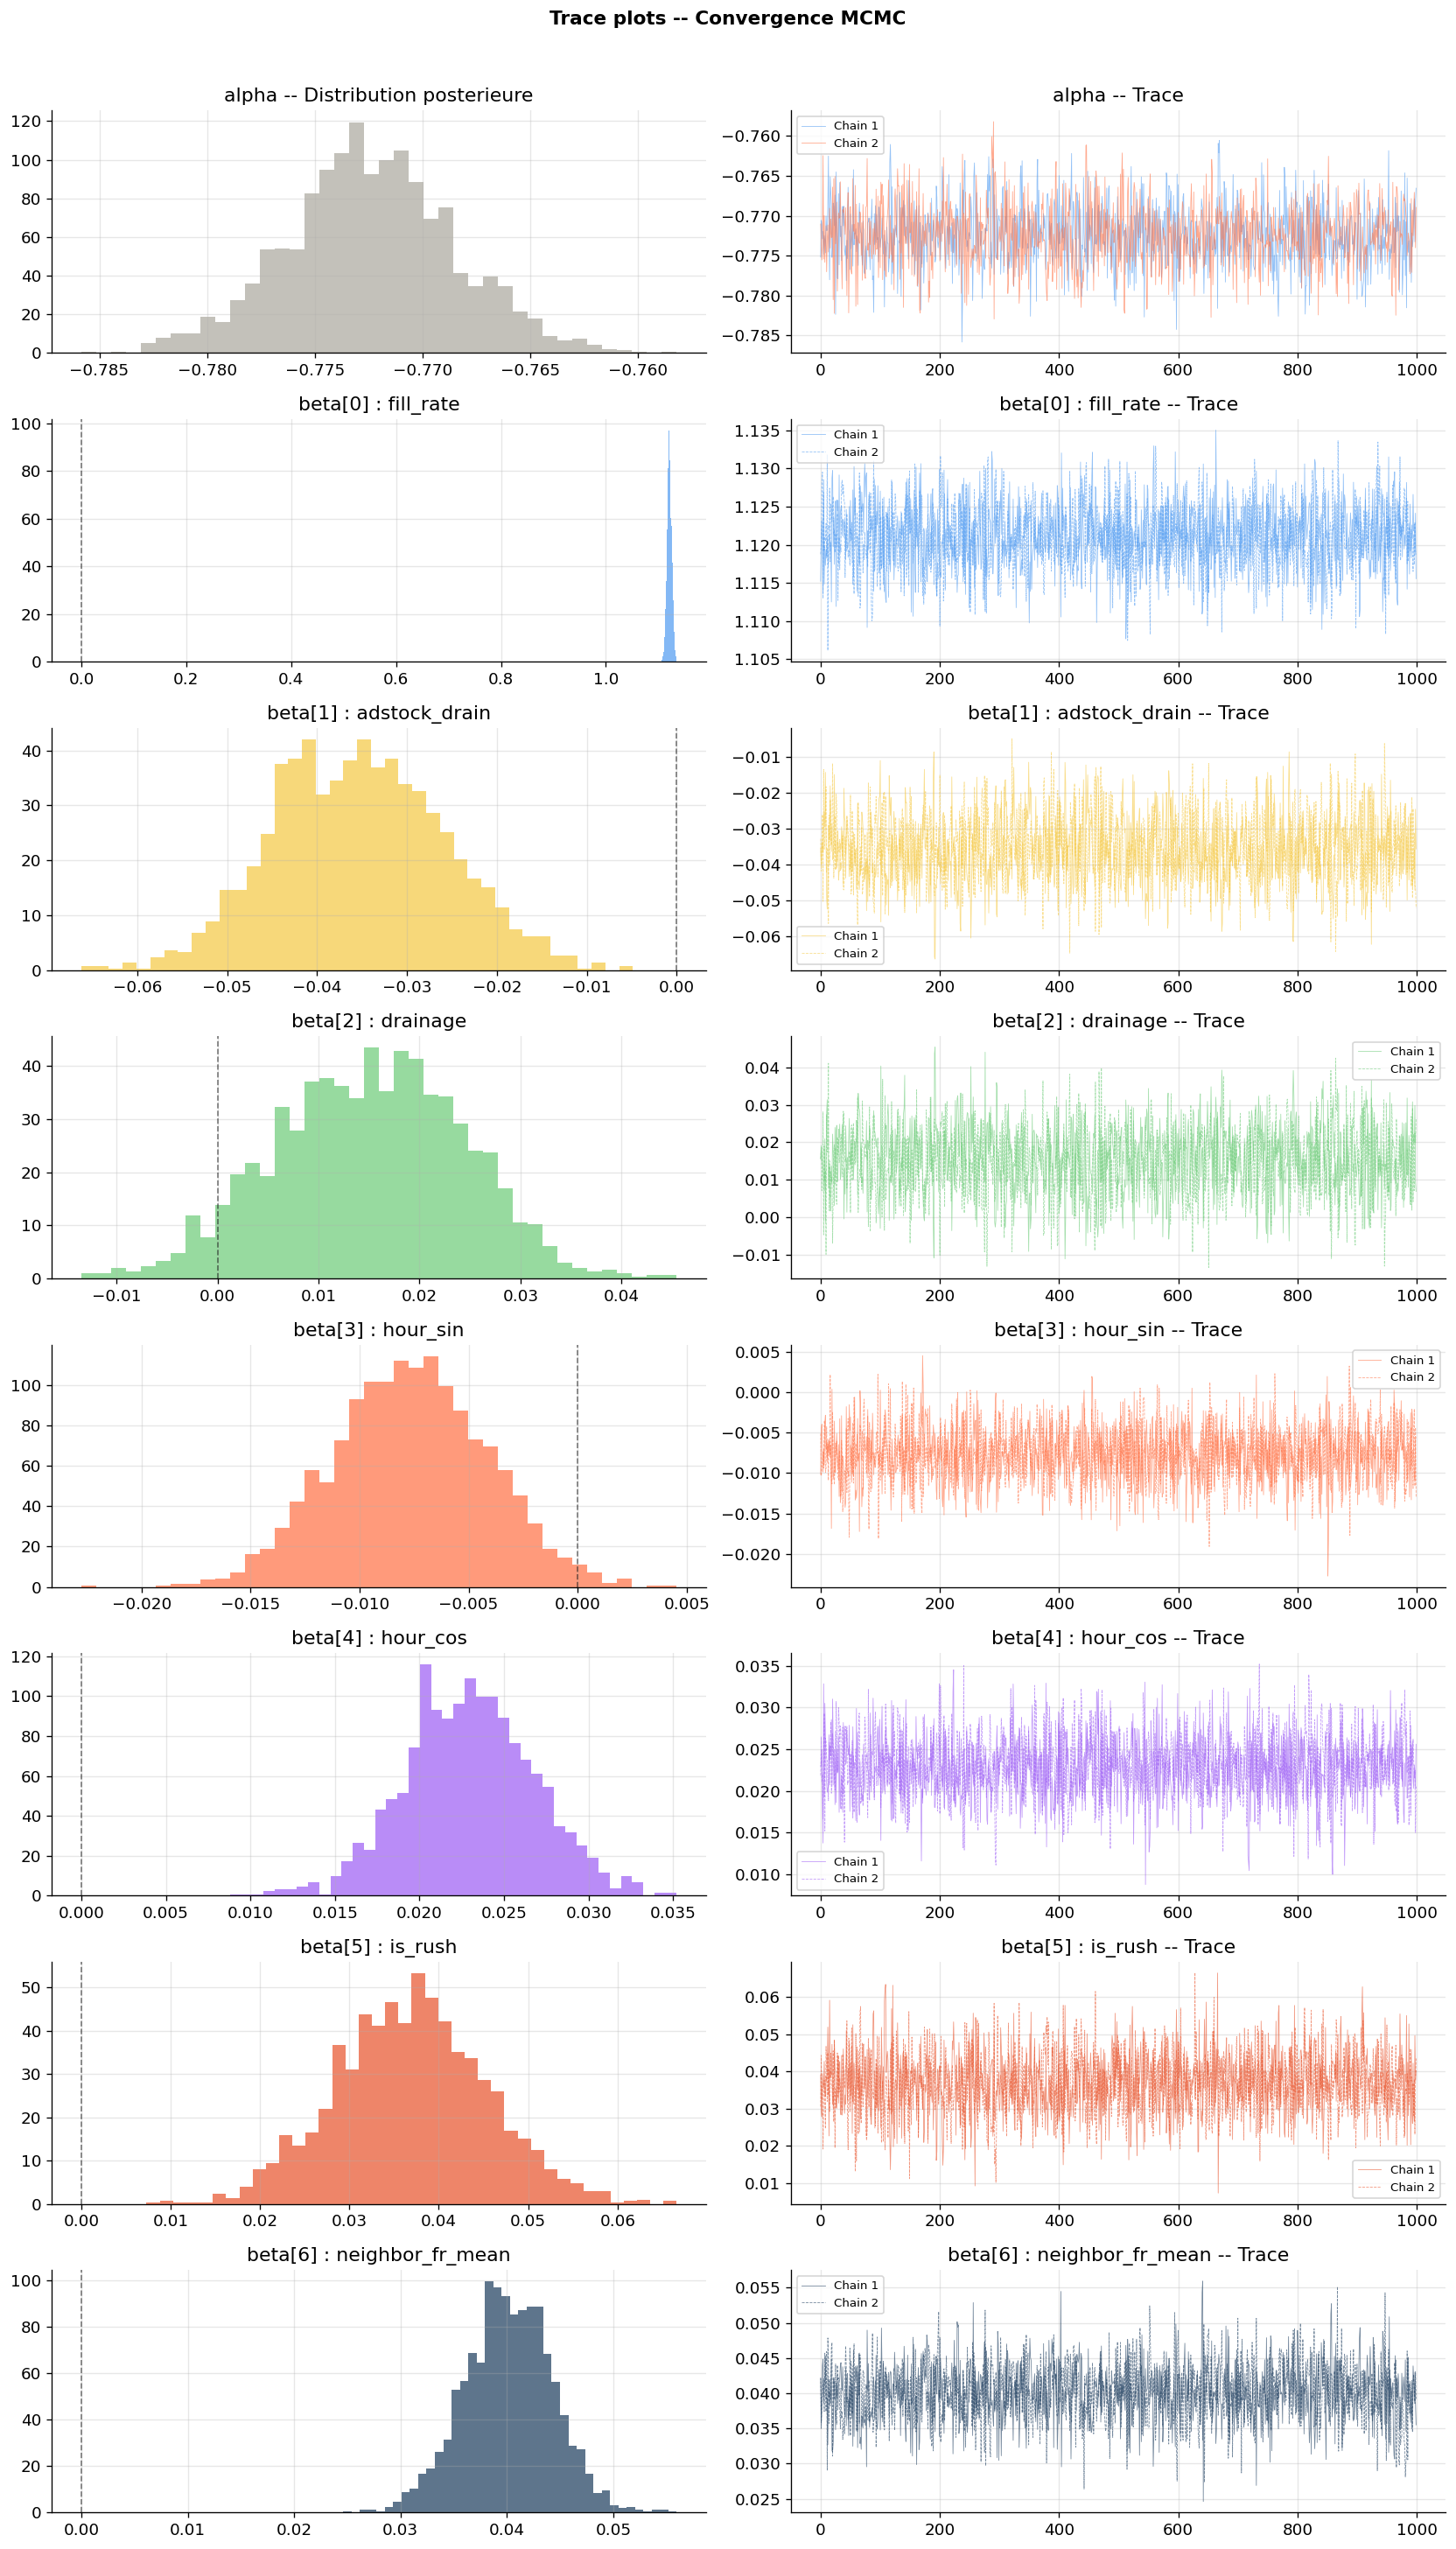

[OK] Figure sauvegardee


In [6]:
# Trace plots -- visualisation des chaines
beta_samples = trace.posterior['beta'].values  # (chains, draws, n_features)

fig, axes = plt.subplots(n_features + 1, 2, figsize=(14, 3*(n_features+1)))
fig.suptitle('Trace plots -- Convergence MCMC', fontsize=13, fontweight='bold', y=1.01)

# Alpha
alpha_samples = trace.posterior['alpha'].values
axes[0,0].hist(alpha_samples.flatten(), bins=40, color='#B4B2A9', alpha=0.8, density=True)
axes[0,0].set_title('alpha -- Distribution posterieure')
axes[0,1].plot(alpha_samples[0], alpha=0.6, linewidth=0.5, color='#4E9AF1', label='Chain 1')
axes[0,1].plot(alpha_samples[1], alpha=0.6, linewidth=0.5, color='#FF7043', label='Chain 2')
axes[0,1].set_title('alpha -- Trace')
axes[0,1].legend(fontsize=8)

# Beta par feature
colors_feat = ['#4E9AF1','#F5C842','#6BCB77','#FF7043','#9C5CF5','#E8522A','#1A3A5C']
for i, feat in enumerate(MODEL_FEATURES):
    color = colors_feat[i % len(colors_feat)]
    samples_i = beta_samples[:, :, i]

    axes[i+1,0].hist(samples_i.flatten(), bins=40, color=color, alpha=0.7, density=True)
    axes[i+1,0].axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    axes[i+1,0].set_title(f'beta[{i}] : {feat}')

    axes[i+1,1].plot(samples_i[0], alpha=0.6, linewidth=0.5, color=color, label='Chain 1')
    axes[i+1,1].plot(samples_i[1], alpha=0.6, linewidth=0.5,
                     color=color, linestyle='--', label='Chain 2')
    axes[i+1,1].set_title(f'beta[{i}] : {feat} -- Trace')
    axes[i+1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(str(FIG_DIR / '03_trace_plots.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 5. Distributions posterieures des coefficients

Chaque distribution posterieure represente notre croyance sur le
coefficient **apres** avoir vu les donnees.

- IC etroit = coefficient bien identifie
- IC large  = incertitude elevee (manque de donnees ou colinearite)
- IC excluant 0 = effet statistiquement credible

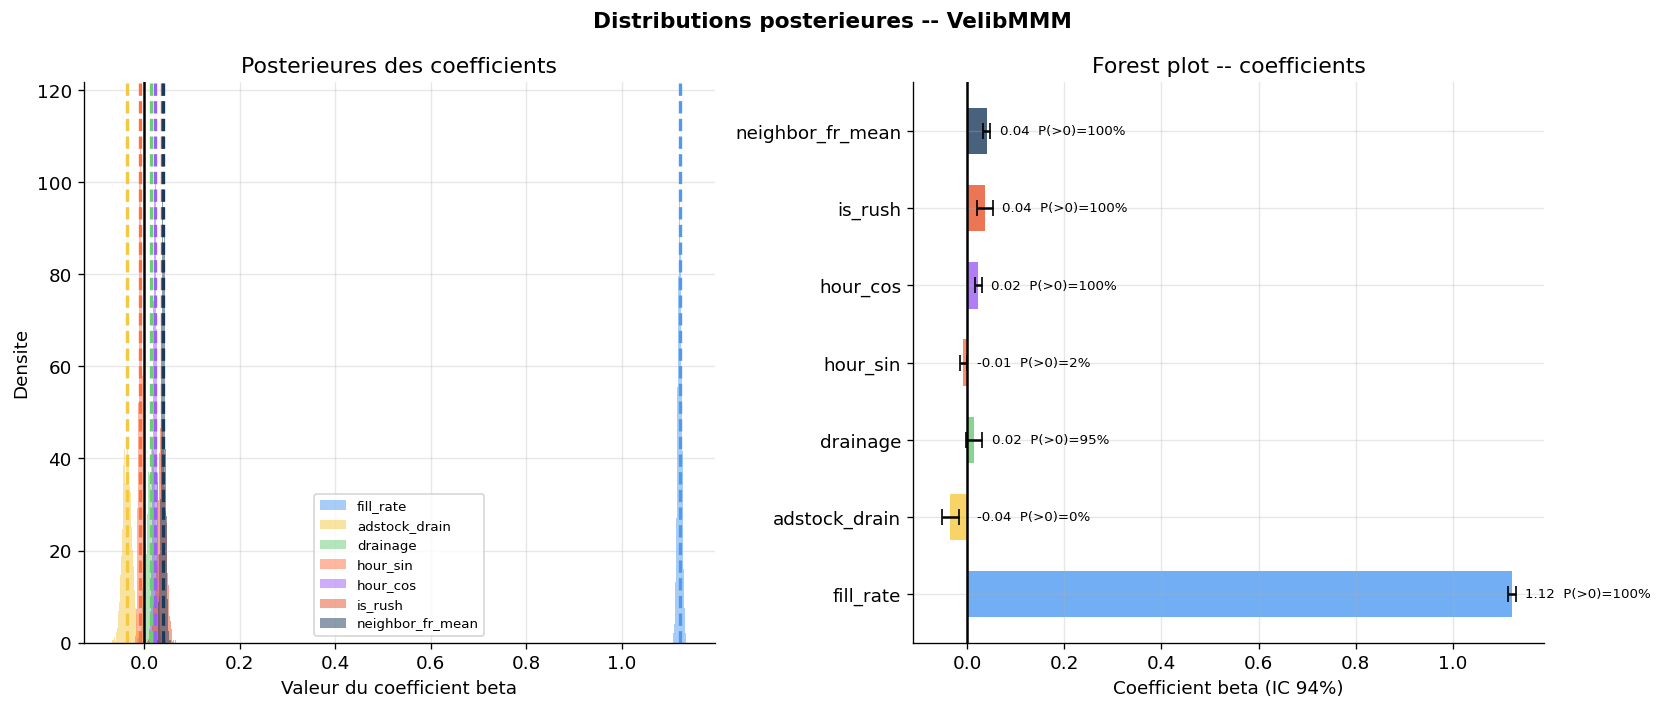

=== Posterieures des coefficients beta ===
Feature                       Mean    IC94 lo    IC94 hi    P(>0)
-----------------------------------------------------------------
fill_rate                    1.121      1.113      1.129   100.0%  [credible]
adstock_drain               -0.035     -0.052     -0.017     0.0%  [credible]
drainage                     0.015     -0.003      0.032    94.7%  [incertain]
hour_sin                    -0.008     -0.014     -0.001     1.6%  [credible]
hour_cos                     0.023      0.016      0.030   100.0%  [credible]
is_rush                      0.037      0.021      0.053   100.0%  [credible]
neighbor_fr_mean             0.040      0.032      0.048   100.0%  [credible]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distributions posterieures -- VelibMMM', fontsize=13, fontweight='bold')

# Posterieures des beta
ax = axes[0]
beta_flat = beta_samples.reshape(-1, n_features)

means_post  = []
lo_94_list  = []
hi_94_list  = []
prob_pos    = []

for i, feat in enumerate(MODEL_FEATURES):
    s = beta_flat[:, i]
    means_post.append(s.mean())
    lo_94_list.append(np.percentile(s, 3))
    hi_94_list.append(np.percentile(s, 97))
    prob_pos.append((s > 0).mean())

    color = colors_feat[i % len(colors_feat)]
    ax.hist(s, bins=40, alpha=0.5, density=True, color=color, label=feat)
    ax.axvline(x=s.mean(), color=color, linewidth=2, linestyle='--')

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Valeur du coefficient beta')
ax.set_ylabel('Densite')
ax.set_title('Posterieures des coefficients')
ax.legend(fontsize=8)

# Forest plot : mean + IC 94%
ax2 = axes[1]
y_pos = range(n_features)
ax2.barh(y_pos, means_post,
         color=[colors_feat[i%len(colors_feat)] for i in range(n_features)],
         alpha=0.8, height=0.6)
ax2.errorbar(
    means_post, y_pos,
    xerr=[np.array(means_post)-np.array(lo_94_list),
          np.array(hi_94_list)-np.array(means_post)],
    fmt='none', color='black', capsize=5, linewidth=1.5
)
ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(MODEL_FEATURES)
ax2.set_xlabel('Coefficient beta (IC 94%)')
ax2.set_title('Forest plot -- coefficients')

for i, (m, lo, hi, pp) in enumerate(zip(means_post, lo_94_list, hi_94_list, prob_pos)):
    txt = f'{m:.2f}  P(>0)={pp:.0%}'
    ax2.text(max(hi, 0) + 0.02, i, txt, va='center', fontsize=8)

plt.tight_layout()
plt.savefig(str(FIG_DIR / '03_posterieures.png'), bbox_inches='tight', dpi=150)
plt.show()

print('=== Posterieures des coefficients beta ===')
print(f'{"Feature":<25} {"Mean":>8} {"IC94 lo":>10} {"IC94 hi":>10} {"P(>0)":>8}')
print('-' * 65)
for i, feat in enumerate(MODEL_FEATURES):
    m  = means_post[i]
    lo = lo_94_list[i]
    hi = hi_94_list[i]
    pp = prob_pos[i]
    sig = '[credible]' if lo > 0 or hi < 0 else '[incertain]'
    print(f'{feat:<25} {m:>8.3f} {lo:>10.3f} {hi:>10.3f} {pp:>8.1%}  {sig}')

## 6. Predictions et validation

On genere les **predictions posterieures** -- pour chaque observation,
on a une distribution de predictions plutot qu'un seul chiffre.
On utilise la moyenne posterieure comme point estimate.

=== Metriques de prediction ===
MAE  : 0.0427  (erreur absolue moyenne sur fill_rate)
RMSE : 0.0653
R2   : 0.9191
r    : 0.9593  (correlation predit vs reel)


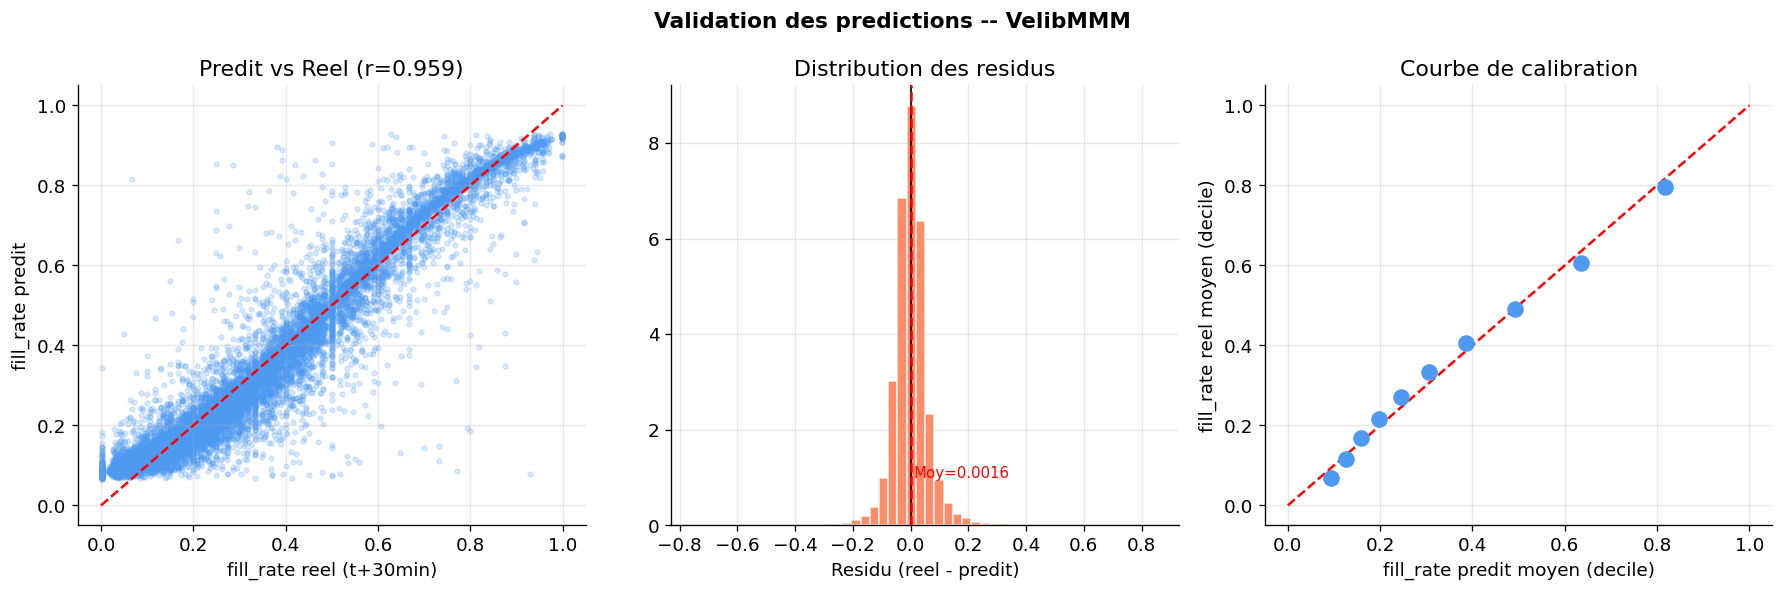

[OK] Figure sauvegardee


In [8]:
# Predictions avec les moyennes posterieures
alpha_mean = trace.posterior['alpha'].values.mean()
beta_mean  = beta_flat.mean(axis=0)
kappa_mean = trace.posterior['kappa'].values.mean()

logit_mu_pred = alpha_mean + X_arr @ beta_mean
mu_pred = 1 / (1 + np.exp(-logit_mu_pred))  # sigmoid

y_true = y_arr
y_pred = mu_pred

# Metriques
mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
r2   = 1 - np.var(y_true - y_pred) / np.var(y_true)
r    = np.corrcoef(y_true, y_pred)[0,1]

print('=== Metriques de prediction ===')
print(f'MAE  : {mae:.4f}  (erreur absolue moyenne sur fill_rate)')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')
print(f'r    : {r:.4f}  (correlation predit vs reel)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Validation des predictions -- VelibMMM', fontsize=13, fontweight='bold')

# Scatter predit vs reel
ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.2, s=8, color='#4E9AF1')
ax.plot([0,1],[0,1], color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('fill_rate reel (t+30min)')
ax.set_ylabel('fill_rate predit')
ax.set_title(f'Predit vs Reel (r={r:.3f})')

# Distribution des residus
ax2 = axes[1]
residus = y_true - y_pred
ax2.hist(residus, bins=50, color='#FF7043', alpha=0.8, edgecolor='white', density=True)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.axvline(x=residus.mean(), color='red', linestyle='--')
mres = residus.mean()
ax2.annotate(f'Moy={mres:.4f}', xy=(mres+0.01, 1), fontsize=9, color='red')
ax2.set_xlabel('Residu (reel - predit)')
ax2.set_title('Distribution des residus')

# Calibration : predit vs reel par decile
ax3 = axes[2]
df_cal = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
df_cal['decile'] = pd.qcut(y_pred, q=10, labels=False, duplicates='drop')
cal = df_cal.groupby('decile')[['y_true','y_pred']].mean()
ax3.scatter(cal['y_pred'], cal['y_true'], s=80, color='#4E9AF1', zorder=5)
ax3.plot([0,1],[0,1], color='red', linewidth=1.5, linestyle='--')
ax3.set_xlabel('fill_rate predit moyen (decile)')
ax3.set_ylabel('fill_rate reel moyen (decile)')
ax3.set_title('Courbe de calibration')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '03_predictions.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

### Incertitude sur les predictions

L'avantage du bayesien : on peut quantifier l'incertitude sur chaque prediction.
On calcule l'IC 94% des predictions posterieures pour 5 stations exemple.

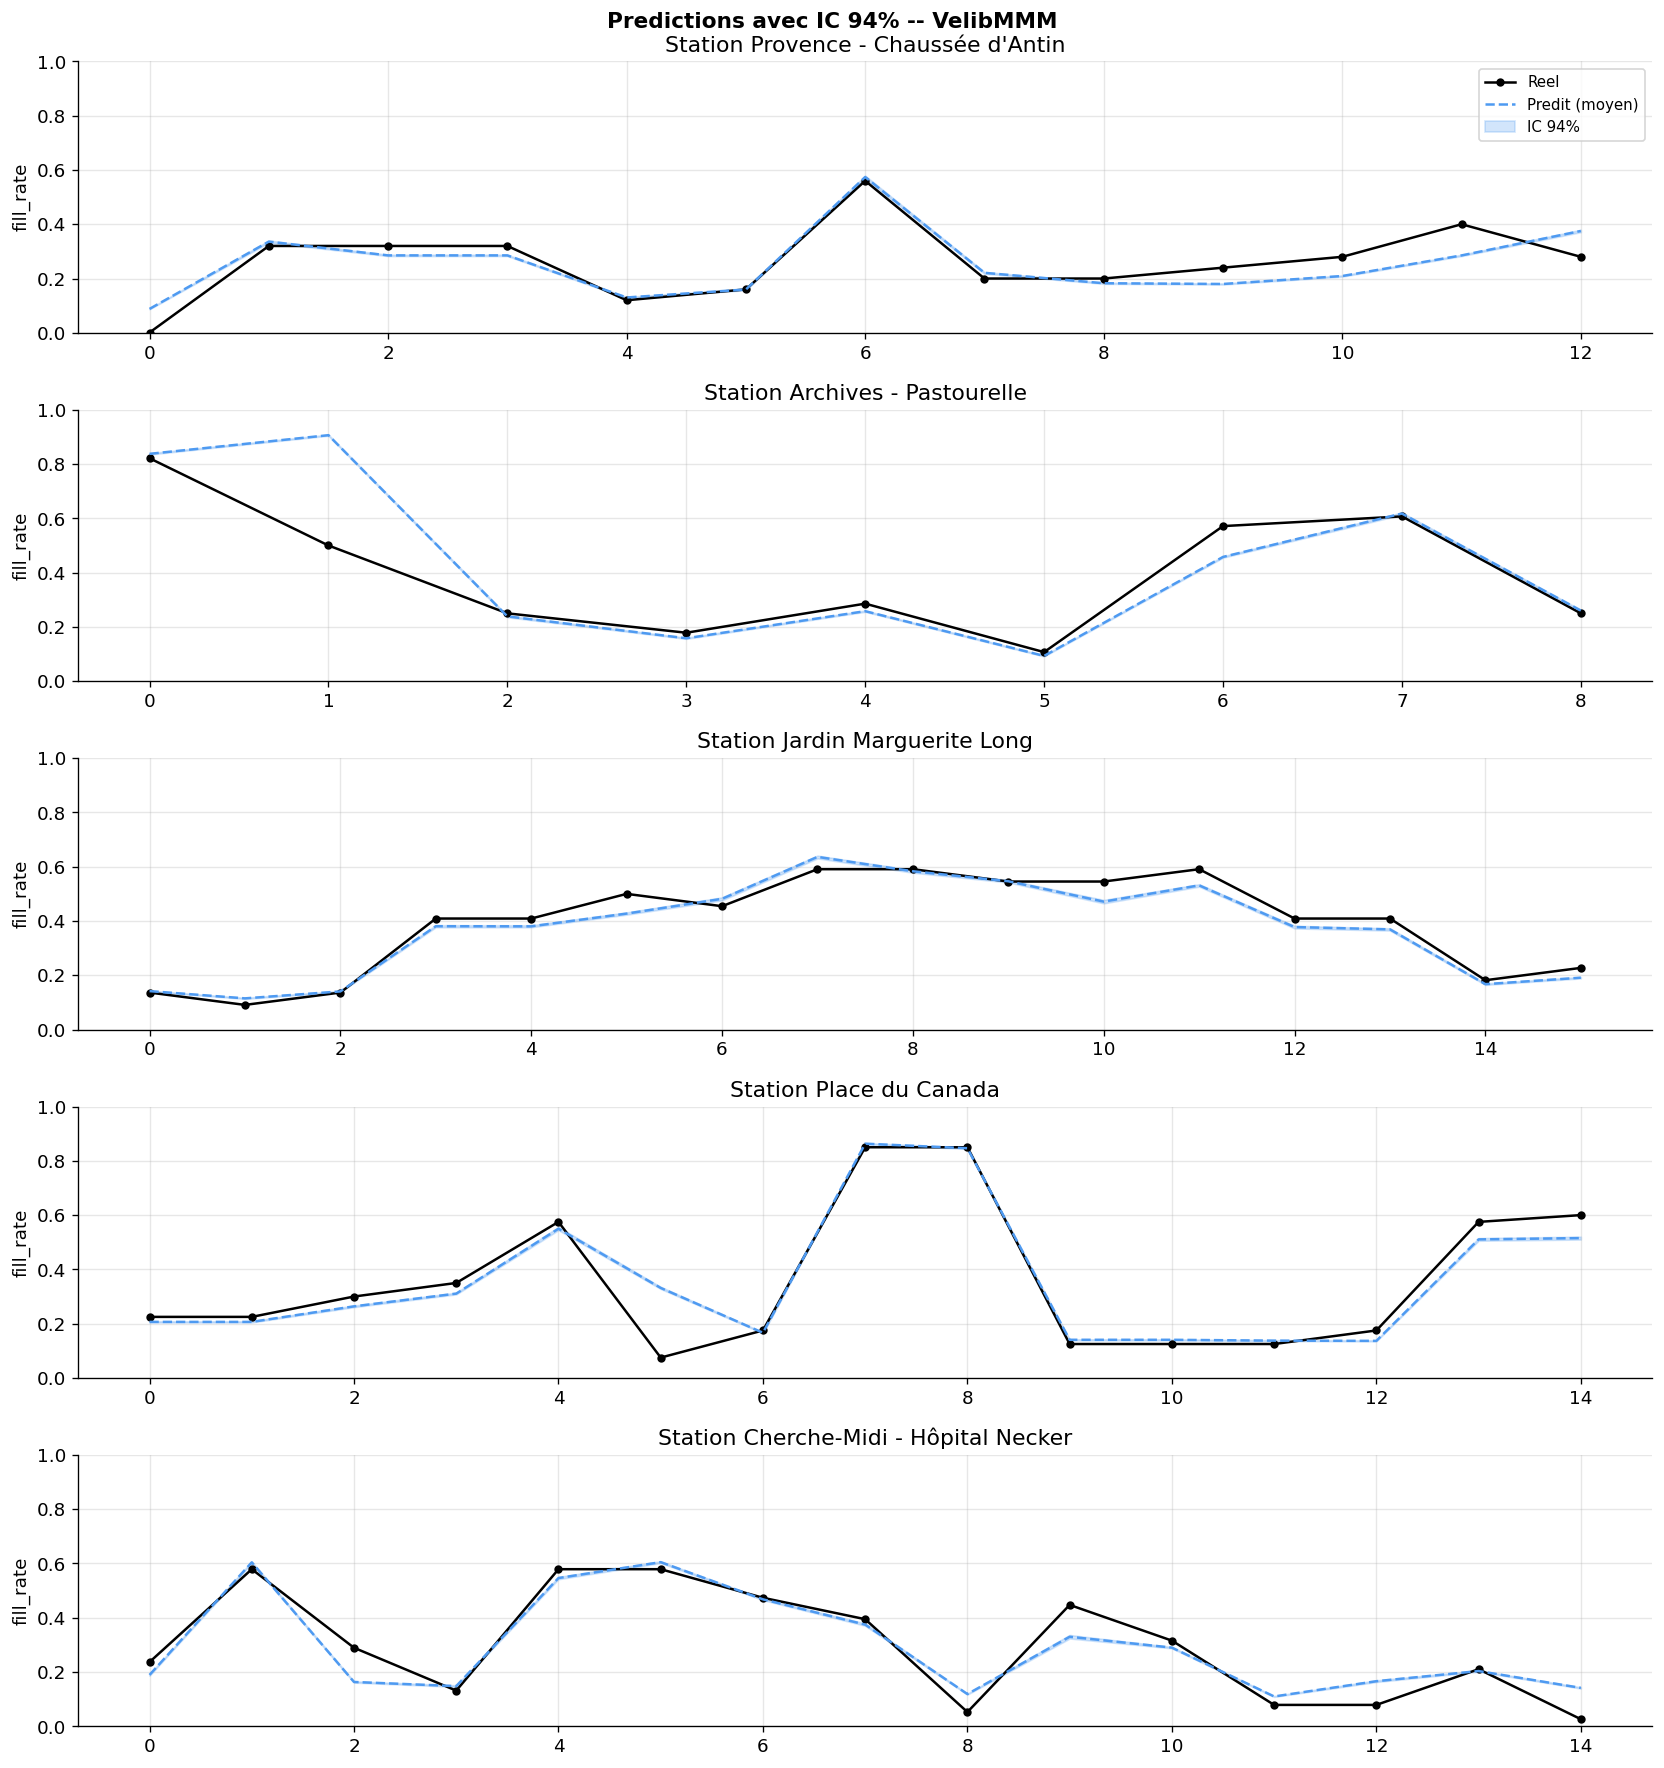

[OK] Figure sauvegardee


In [9]:
# Predictions avec incertitude pour un subset de stations
N_POSTERIOR_SAMPLES = 500

# Echantillons posterieurs
alpha_post = trace.posterior['alpha'].values.flatten()[:N_POSTERIOR_SAMPLES]
beta_post  = beta_flat[:N_POSTERIOR_SAMPLES, :]

# Predictions pour chaque echantillon
logit_mu_post = alpha_post[:, None] + (beta_post @ X_arr.T)  # (N_samples, N_obs)
mu_post = 1 / (1 + np.exp(-logit_mu_post))

pred_mean = mu_post.mean(axis=0)
pred_lo   = np.percentile(mu_post, 3, axis=0)
pred_hi   = np.percentile(mu_post, 97, axis=0)

# Visualisation sur quelques stations
stations_ex = df_sample['station_id'].unique()[:5]

fig, axes = plt.subplots(len(stations_ex), 1, figsize=(14, 3*len(stations_ex)))
if len(stations_ex) == 1:
    axes = [axes]
fig.suptitle('Predictions avec IC 94% -- VelibMMM', fontsize=13, fontweight='bold')

for i, sid in enumerate(stations_ex):
    mask = df_sample['station_id'] == sid
    idx  = np.where(mask)[0]
    if len(idx) == 0:
        continue

    ts = df_sample.loc[mask, 'ts_utc'].values
    order = np.argsort(ts)
    idx_sorted = idx[order]

    ax = axes[i]
    ax.plot(range(len(idx_sorted)), y_true[idx_sorted],
            color='black', linewidth=1.5, label='Reel', marker='o', markersize=4)
    ax.plot(range(len(idx_sorted)), pred_mean[idx_sorted],
            color='#4E9AF1', linewidth=1.5, linestyle='--', label='Predit (moyen)')
    ax.fill_between(range(len(idx_sorted)),
                    pred_lo[idx_sorted], pred_hi[idx_sorted],
                    alpha=0.25, color='#4E9AF1', label='IC 94%')
    ax.set_title(f'Station {sid}')
    ax.set_ylabel('fill_rate')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(FIG_DIR / '03_predictions_ic.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 7. Interpretation consultant

Les coefficients beta sont sur l'echelle logit -- on calcule l'**odds ratio**
pour les interpreter en termes de fill_rate :

```
Odds ratio = exp(beta)
OR > 1 : la feature augmente la probabilite d'avoir plus de velos
OR < 1 : la feature diminue la disponibilite
```

In [10]:
print('=' * 68)
print('  INTERPRETATION DES COEFFICIENTS -- VelibMMM')
print('=' * 68)
print()
print(f'{"Feature":<25} {"Beta mean":>10} {"Odds Ratio":>12} {"P(>0)":>8} {"Interpretation"}')
print('-' * 68)

interpretations = {
    'fill_rate':         'Plus la station est pleine maintenant, plus elle le sera dans 30min',
    'adstock_drain':     'Memoire du drainage : plus on a perdu de velos, moins il y en aura',
    'drainage':          'Drainage instantane : forte sortie de velos -> moins disponibles',
    'hour_sin':          'Periodicite horaire (composante sin)',
    'hour_cos':          'Periodicite horaire (composante cos)',
    'is_rush':           'Heure de pointe : impact sur la disponibilite',
    'neighbor_fr_mean':  'Si les voisins ont des velos, la station en aura aussi',
}

for i, feat in enumerate(MODEL_FEATURES):
    m  = means_post[i]
    pp = prob_pos[i]
    lo = lo_94_list[i]
    hi = hi_94_list[i]
    OR = np.exp(m)
    sig = '' if (lo < 0 < hi) else '***'
    interp = interpretations.get(feat, '')
    print(f'{feat:<25} {m:>10.3f} {OR:>12.3f} {pp:>8.1%} {sig}')
    if interp:
        print(f'  -> {interp}')

print()
print(f'kappa (precision Beta) : {kappa_mean:.2f}')
print(f'  -> Plus kappa est eleve, plus les predictions sont concentrees')
print(f'  -> kappa = {kappa_mean:.0f} signifie une variance de mu*(1-mu)/({kappa_mean:.0f}+1)')

  INTERPRETATION DES COEFFICIENTS -- VelibMMM

Feature                    Beta mean   Odds Ratio    P(>0) Interpretation
--------------------------------------------------------------------
fill_rate                      1.121        3.068   100.0% ***
  -> Plus la station est pleine maintenant, plus elle le sera dans 30min
adstock_drain                 -0.035        0.965     0.0% ***
  -> Memoire du drainage : plus on a perdu de velos, moins il y en aura
drainage                       0.015        1.015    94.7% 
  -> Drainage instantane : forte sortie de velos -> moins disponibles
hour_sin                      -0.008        0.992     1.6% ***
  -> Periodicite horaire (composante sin)
hour_cos                       0.023        1.023   100.0% ***
  -> Periodicite horaire (composante cos)
is_rush                        0.037        1.038   100.0% ***
  -> Heure de pointe : impact sur la disponibilite
neighbor_fr_mean               0.040        1.041   100.0% ***
  -> Si les voisins on

## 8. Sauvegarde

In [11]:
# Sauvegarder la trace ArviZ
trace.to_netcdf(str(MOD_DIR / 'velib_bayes_trace.nc'))

# Sauvegarder les parametres posterieurs + config normalisation
model_artifacts = {
    'alpha_mean':    float(alpha_mean),
    'beta_mean':     beta_mean.tolist(),
    'kappa_mean':    float(kappa_mean),
    'model_features':MODEL_FEATURES,
    'continuous_features': CONTINUOUS,
    'norm_means':    means_.to_dict(),
    'norm_stds':     stds_.to_dict(),
    'metrics': {
        'mae':  float(mae),
        'rmse': float(rmse),
        'r2':   float(r2),
        'r':    float(r),
    },
    'rhat_max':   float(rhat_max),
    'ess_min':    float(ess_min),
    'divergences': int(diverg),
}
(MOD_DIR / 'velib_model_artifacts.json').write_text(
    json.dumps(model_artifacts, indent=2)
)

print('[OK] Trace sauvegardee     : outputs/models/velib_bayes_trace.nc')
print('[OK] Artefacts sauvegardes : outputs/models/velib_model_artifacts.json')

[OK] Trace sauvegardee     : outputs/models/velib_bayes_trace.nc
[OK] Artefacts sauvegardes : outputs/models/velib_model_artifacts.json


## 9. Synthese

In [12]:
print('=' * 68)
print('  SYNTHESE -- MODELE BAYESIEN VELIBMMM')
print('=' * 68)
print()
print('CONVERGENCE MCMC')
print(f'  R-hat max   : {rhat_max:.4f}  {"[OK]" if rhat_max < 1.01 else "[ATTENTION]"}')
print(f'  ESS min     : {ess_min:.0f}    {"[OK]" if ess_min > 400 else "[ATTENTION]"}')
print(f'  Divergences : {diverg}       {"[OK]" if diverg == 0 else "[ATTENTION]"}')
print()
print('PERFORMANCE PREDICTIVE')
print(f'  MAE  : {mae:.4f}  (erreur absolue moyenne)')
print(f'  RMSE : {rmse:.4f}')
print(f'  R2   : {r2:.4f}  ({r2*100:.1f}% variance expliquee)')
print()
print('POSTERIEURES BETA (logit scale)')
for i, feat in enumerate(MODEL_FEATURES):
    m  = means_post[i]
    lo = lo_94_list[i]
    hi = hi_94_list[i]
    pp = prob_pos[i]
    sig = '[credible]' if (lo > 0 or hi < 0) else '[incertain]'
    print(f'  {feat:<25} {m:>+7.3f}  IC=[{lo:.3f},{hi:.3f}]  P(>0)={pp:.1%}  {sig}')
print()
print('CONNEXION AVEC LES CHAINES DE MARKOV')
print('  Les echantillons NUTS sont des tirages de P(theta | donnees)')
print('  La chaine a converge : les 2 chaines explorent le meme espace')
print('  Chaque beta est une distribution, pas un point')
print()
print('PROCHAINE ETAPE --> Notebook 04 : Dashboard temps reel')
print('  - Carte Folium interactive avec predictions en direct')
print('  - Alertes stations critiques (fill_rate_t30 < 0.1)')
print('  - IC bayesien sur chaque prediction')
print('=' * 68)

  SYNTHESE -- MODELE BAYESIEN VELIBMMM

CONVERGENCE MCMC
  R-hat max   : 1.0000  [OK]
  ESS min     : 1518    [OK]
  Divergences : 0       [OK]

PERFORMANCE PREDICTIVE
  MAE  : 0.0427  (erreur absolue moyenne)
  RMSE : 0.0653
  R2   : 0.9191  (91.9% variance expliquee)

POSTERIEURES BETA (logit scale)
  fill_rate                  +1.121  IC=[1.113,1.129]  P(>0)=100.0%  [credible]
  adstock_drain              -0.035  IC=[-0.052,-0.017]  P(>0)=0.0%  [credible]
  drainage                   +0.015  IC=[-0.003,0.032]  P(>0)=94.7%  [incertain]
  hour_sin                   -0.008  IC=[-0.014,-0.001]  P(>0)=1.6%  [credible]
  hour_cos                   +0.023  IC=[0.016,0.030]  P(>0)=100.0%  [credible]
  is_rush                    +0.037  IC=[0.021,0.053]  P(>0)=100.0%  [credible]
  neighbor_fr_mean           +0.040  IC=[0.032,0.048]  P(>0)=100.0%  [credible]

CONNEXION AVEC LES CHAINES DE MARKOV
  Les echantillons NUTS sont des tirages de P(theta | donnees)
  La chaine a converge : les 2 chai